# Scaling Comparison

Compare `96_96_L.csv` and `96_96_R.csv` on one figure with MACs on the x-axis.


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [7]:
aie_latency = np.asarray([695.2,
                         1393.6,
                         2084.8,
                         2790.4,
                          3495.2,
                           4192.8 ] )

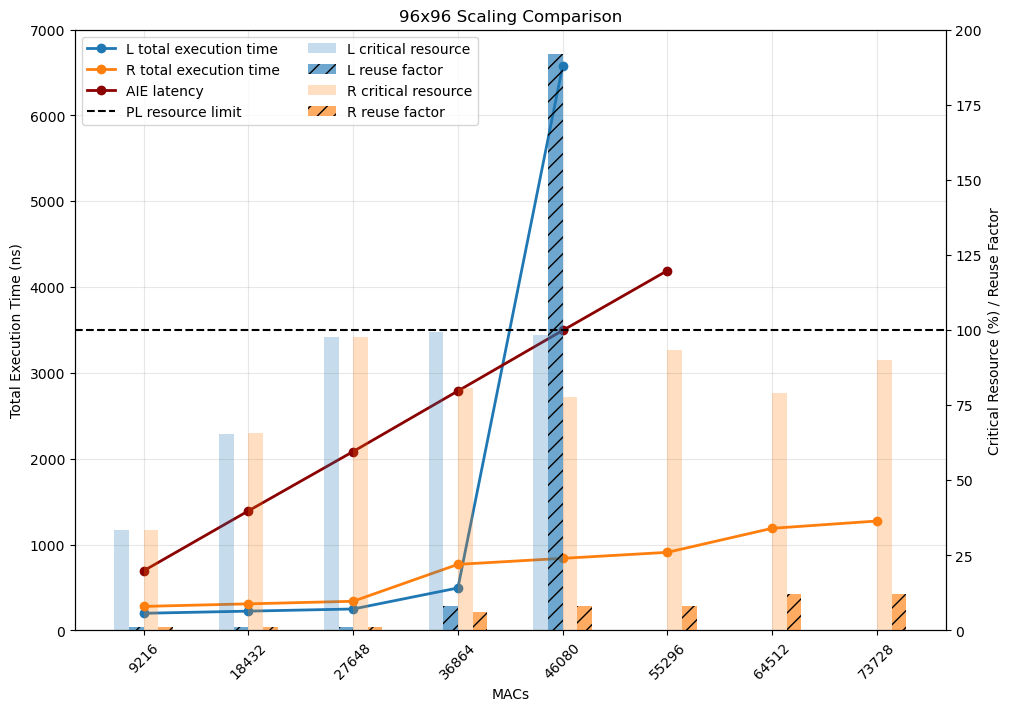

In [12]:
figsize = (10, 7)
time_ylim = (0, 7000)
bar_ylim = (0, 200)
l_color = "#1f77b4"
r_color = "#ff7f0e"
aie_color = "#8b0000"

base = Path(".")
l_df = pd.read_csv(base / "96_96_L.csv").sort_values("MACs")
r_df = pd.read_csv(base / "96_96_R.csv").sort_values("MACs")

l_df["total execution time"] = l_df["total execution time"] * 5
r_df["total execution time"] = r_df["total execution time"] * 5
l_df["critical_resource"] = l_df[["LUT", "FF", "BRAM"]].max(axis=1)
r_df["critical_resource"] = r_df[["LUT", "FF", "BRAM"]].max(axis=1)

aie_macs = 96 * 96 * np.arange(1, len(aie_latency) + 1)
all_macs = np.sort(np.unique(np.concatenate([l_df["MACs"], r_df["MACs"], aie_macs])))
bar_width = np.min(np.diff(all_macs)) * 0.14

fig, ax_time = plt.subplots(figsize=figsize, constrained_layout=True)
ax_bar = ax_time.twinx()

ax_time.plot(l_df["MACs"], l_df["total execution time"], marker="o", linewidth=2, color=l_color, label="L total execution time")
ax_time.plot(r_df["MACs"], r_df["total execution time"], marker="o", linewidth=2, color=r_color, label="R total execution time")
ax_time.plot(aie_macs, aie_latency, marker="o", linewidth=2, color=aie_color, label="AIE latency")

ax_bar.bar(l_df["MACs"] - 1.5 * bar_width, l_df["critical_resource"], width=bar_width, color=l_color, alpha=0.25, label="L critical resource")
ax_bar.bar(l_df["MACs"] - 0.5 * bar_width, l_df["rf"], width=bar_width, color=l_color, alpha=0.65, hatch="//", label="L reuse factor")
ax_bar.bar(r_df["MACs"] + 0.5 * bar_width, r_df["critical_resource"], width=bar_width, color=r_color, alpha=0.25, label="R critical resource")
ax_bar.bar(r_df["MACs"] + 1.5 * bar_width, r_df["rf"], width=bar_width, color=r_color, alpha=0.65, hatch="//", label="R reuse factor")
ax_bar.axhline(100, color="black", linestyle="--", linewidth=1.5, label="PL resource limit")

ax_time.set_title("96x96 Scaling Comparison")
ax_time.set_xlabel("MACs")
ax_time.set_ylabel("Total Execution Time (ns)")
ax_bar.set_ylabel("Critical Resource (%) / Reuse Factor")
ax_time.set_xticks(all_macs)
ax_time.ticklabel_format(style="plain", axis="x")
ax_time.tick_params(axis="x", rotation=45)
ax_time.grid(alpha=0.3)

if time_ylim is not None:
    ax_time.set_ylim(time_ylim)
if bar_ylim is not None:
    ax_bar.set_ylim(bar_ylim)

time_handles, time_labels = ax_time.get_legend_handles_labels()
bar_handles, bar_labels = ax_bar.get_legend_handles_labels()
ax_time.legend(time_handles + bar_handles, time_labels + bar_labels, loc="upper left", ncol=2)

plt.show()
